In [1]:
!pip install git+https://github.com/justingeeslin/Real-Time-Object-Measurement

  Cloning https://github.com/justingeeslin/Real-Time-Object-Measurement to /private/var/folders/cr/f_0wmkcd5dgf619y8b4xp2740000gq/T/pip-req-build-bfb73l78
  Running command git clone --filter=blob:none --quiet https://github.com/justingeeslin/Real-Time-Object-Measurement /private/var/folders/cr/f_0wmkcd5dgf619y8b4xp2740000gq/T/pip-req-build-bfb73l78
  Resolved https://github.com/justingeeslin/Real-Time-Object-Measurement to commit a1fcb5a516690294d87383e60207575e1ffa2bad
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for ObjectMeasurer: filename=objectmeasurer-0.1.1-py3-none-any.whl size=6436 sha256=e7453de1c59b224487f2a3500344741b8490bbefaa30a54f80188e02944f503e
  Stored in directory: /private/var/folders/cr/f_0wmkcd5dgf619y8b4xp2740000gq/T/pip-ephem-wheel-cache-em2gev7d/wheels/87/d4/79/c1a201f493cf43501fa66f85e9f5e04cd8273c0116378e71a9
Successfully built ObjectMeasurer
  Attempting

In [2]:
import cv2
from ObjectMeasurer import ObjectMeasurer

# SHORT SIDE / X-AXIS FIRST
# A4_MM = (210.0, 297.0)
LETTER_MM = (215.9, 279.4)  # 8.5in x 11in

In [3]:
import os

image_url = "https://raw.githubusercontent.com/justingeeslin/Real-Time-Object-Measurement/main/test-images/ucard-one-off-axis/ucard-one-off-axis.jpg"
image_name = "ucard-one-off-axis.jpg"

# Download the image
!wget -O {image_name} {image_url}

# Verify the download
if os.path.exists(image_name) and os.path.getsize(image_name) > 0:
    print(f"Successfully downloaded {image_name}")
else:
    print(f"Failed to download {image_name} or the file is empty.")

--2026-03-04 13:50:26--  https://raw.githubusercontent.com/justingeeslin/Real-Time-Object-Measurement/main/test-images/ucard-one-off-axis/ucard-one-off-axis.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 2606:50c0:8003::154, 2606:50c0:8002::154, 2606:50c0:8000::154, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|2606:50c0:8003::154|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1062597 (1.0M) [image/jpeg]
Saving to: ‘ucard-one-off-axis.jpg’

ucard-one-off-axis. 100%[===================>]   1.01M  --.-KB/s    in 0.04s   

2026-03-04 13:50:26 (27.8 MB/s) - ‘ucard-one-off-axis.jpg’ saved [1062597/1062597]

Successfully downloaded ucard-one-off-axis.jpg


In [4]:
import cv2
from ObjectMeasurer import ObjectMeasurer

# SHORT SIDE / X-AXIS FIRST
# A4_MM = (210.0, 297.0)
LETTER_MM = (215.9, 279.4)  # 8.5in x 11in

# Open an image with an object you want to measure ontop of another, reference object of known dimensions
img = cv2.imread(image_name) # Changed to read the locally downloaded image

if img is None or img.size == 0:
    print(f"Error: Could not load image from {image_name}. Please ensure the file was downloaded correctly.")
else:
    print(f"Image {image_name} loaded successfully with dimensions: {img.shape}")

Image ucard-one-off-axis.jpg loaded successfully with dimensions: (3024, 3024, 3)


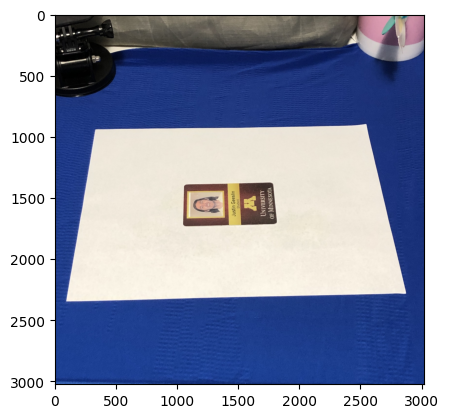

In [7]:
import matplotlib.pyplot as plt
# Show the image in this notebook with matplotlib

# load image using cv2....and do processing.
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
# as opencv loads in BGR format by default, we want to show it in RGB.
plt.show()

In [6]:
# Construct the ObjectMeasurer with the size of the reference object
measurer = ObjectMeasurer(reference_size_mm=LETTER_MM)
# Get the measurements (in cm)
measurements = measurer.measure(img)

print(f"{[(m.width_cm, m.height_cm) for m in measurements]}")

[getContours] kernel_size=5
Swapping width and height
untitled_page angle: 88.72422790527344
untitled_page is landscape, Rotating to portrait..
[getContours] kernel_size=5
[draw bbox] obj#0: w=5.7000cm h=8.8000cm (axis-aligned)
[draw minAreaRect] obj#0: w=8.9000cm h=5.7000cm (rotated)
Using rectangle distance method...
[measure] corners: w=8.70cm h=5.50cm
[(8.700574693662483, 5.500909015790027)]
